In [1]:
from olist.data import get_data
import matplotlib.pyplot as plt

data = get_data()

orders = data['orders']
order_items = data['order_items']
order_reviews = data['order_reviews']
customers = data['customers']
sellers = data['sellers']
products = data['products']

In [2]:
print("=== Tablo Büyüklükleri ===")
print(f"Benzersiz order_id    (orders)       : {orders['order_id'].nunique()}")
print(f"Benzersiz order_id    (order_items)  : {order_items['order_id'].nunique()}")
print(f"Benzersiz order_id    (order_reviews): {order_reviews['order_id'].nunique()}")
print(f"Benzersiz customer_id               : {customers['customer_id'].nunique()}")
print(f"Benzersiz seller_id                 : {sellers['seller_id'].nunique()}")
print(f"Benzersiz product_id                : {products['product_id'].nunique()}")
print(f"Benzersiz review_id                 : {order_reviews['review_id'].nunique()}")

=== Tablo Büyüklükleri ===
Benzersiz order_id    (orders)       : 99441
Benzersiz order_id    (order_items)  : 98666
Benzersiz order_id    (order_reviews): 98673
Benzersiz customer_id               : 99441
Benzersiz seller_id                 : 3095
Benzersiz product_id                : 32951
Benzersiz review_id                 : 98410


In [3]:
reviews_per_order = order_reviews.groupby('order_id')['review_id'].count().reset_index()
reviews_per_order.columns = ['order_id', 'review_count']

orders_with_reviews = orders.merge(reviews_per_order, on='order_id', how='left')
orders_with_reviews['review_count'] = orders_with_reviews['review_count'].fillna(0)

print(orders_with_reviews[['order_id', 'review_count']].head(10))

                           order_id  review_count
0  e481f51cbdc54678b7cc49136f2d6af7           1.0
1  53cdb2fc8bc7dce0b6741e2150273451           1.0
2  47770eb9100c2d0c44946d9cf07ec65d           1.0
3  949d5b44dbf5de918fe9c16f97b45f8a           1.0
4  ad21c59c0840e6cb83a9ceb5573f8159           1.0
5  a4591c265e18cb1dcee52889e2d8acc3           1.0
6  136cce7faa42fdb2cefd53fdc79a6098           1.0
7  6514b8ad8028c9f2cc2374ded245783f           1.0
8  76c6e866289321a7c93b82b54852dc33           1.0
9  e69bfb5eb88e0ed6a785585b27e16dbf           1.0


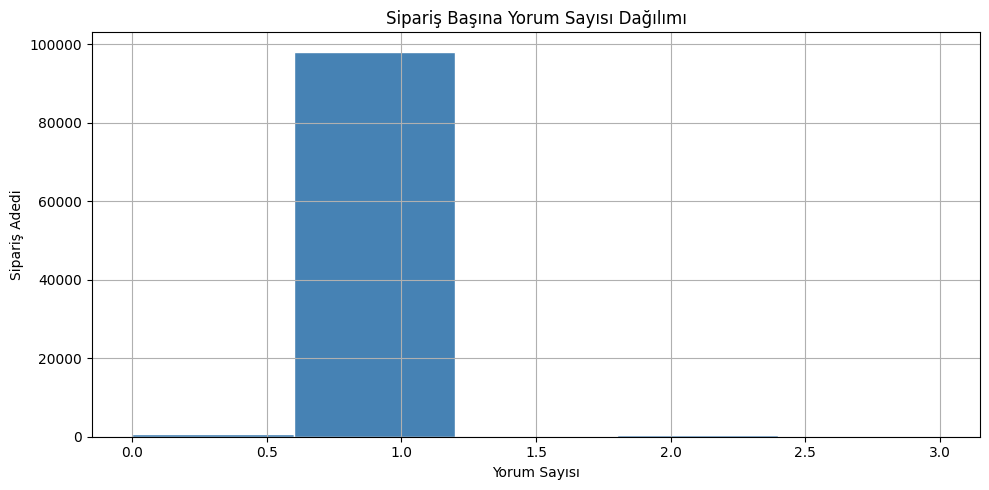

In [4]:
plt.figure(figsize=(10, 5))
orders_with_reviews['review_count'].hist(bins=5, color='steelblue', edgecolor='white')
plt.title('Sipariş Başına Yorum Sayısı Dağılımı')
plt.xlabel('Yorum Sayısı')
plt.ylabel('Sipariş Adedi')
plt.tight_layout()
plt.show()

In [5]:
no_review = orders_with_reviews[orders_with_reviews['review_count'] == 0]
print(f"Toplam sipariş sayısı        : {len(orders)}")
print(f"Yorumu olan sipariş sayısı   : {len(orders) - len(no_review)}")
print(f"Yorumu olmayan sipariş sayısı: {len(no_review)}")
print(f"Eksik yorum oranı            : %{len(no_review)/len(orders)*100:.2f}")

Toplam sipariş sayısı        : 99441
Yorumu olan sipariş sayısı   : 98673
Yorumu olmayan sipariş sayısı: 768
Eksik yorum oranı            : %0.77
